# VITO UrbClim T2M vs ISU GSHTD Temperature Comparison — Salvador, Brazil

Compares two daily temperature datasets over the city of Salvador for the period they share in common (2008–2017):

| Dataset | Source | Resolution | Units | Coverage |
|---------|--------|------------|-------|----------|
| **VITO UrbClim** | Local NetCDF (VITO/UrbClim) | 100 m, EPSG:32724 | Kelvin | 2008–2017 |
| **ISU GSHTD** | Google Earth Engine `sat-io` | 1 km, EPSG:4326 | 0.1 °C | 2003–2020 |

**Spatial alignment:** The ISU 1 km data is clipped to the VITO domain extent (converted to WGS84) and all pixels are averaged per day, giving one spatial-mean value per day per dataset.

**Outputs:**
1. Daily time series of Tmin and Tmax (2008–2017)
2. Monthly 90th / 95th / 99th percentile plots for each dataset
3. Summary comparison table

In [1]:
import ee
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from pathlib import Path
from pyproj import Transformer
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

DATA_DIR = Path('../data')
OUTPUT_DIR = Path('../outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

try:
    ee.Initialize(project='tl-cities')
    print('GEE initialised')
except Exception as e:
    print(f'GEE init failed: {e}')

GEE initialised


## 1. Load VITO UrbClim T2M data

Files: `T2M_year_daily_max_YYYY.nc` and `T2M_year_daily_min_YYYY.nc` for 2008–2017.  
CRS: EPSG:32724 (UTM 24S). Units: Kelvin → convert to °C.

In [2]:
YEARS = range(2008, 2018)

def load_vito_variable(var_type):
    """Load all years of a VITO T2M variable (max or min), spatially average, return daily series."""
    frames = []
    for year in YEARS:
        path = DATA_DIR / f'T2M_year_daily_{var_type}_{year}.nc'
        if not path.exists():
            print(f'  Missing: {path.name}')
            continue
        ds = xr.open_dataset(path)
        # Spatial mean across all pixels, convert K -> C
        daily_mean = ds['T2M'].mean(dim=['x', 'y']) - 273.15
        df = daily_mean.to_dataframe(name=f't{var_type}').reset_index()
        df = df.rename(columns={'time': 'date'})
        df['date'] = pd.to_datetime(df['date']).dt.normalize()
        frames.append(df)
        ds.close()
    return pd.concat(frames, ignore_index=True).sort_values('date').reset_index(drop=True)

print('Loading VITO tmax...')
vito_tmax = load_vito_variable('max')
print(f'  {len(vito_tmax)} days, {vito_tmax.date.min().date()} – {vito_tmax.date.max().date()}')
print(f'  tmax range: {vito_tmax.tmax.min():.1f} – {vito_tmax.tmax.max():.1f} °C')

print('Loading VITO tmin...')
vito_tmin = load_vito_variable('min')
print(f'  {len(vito_tmin)} days, {vito_tmin.date.min().date()} – {vito_tmin.date.max().date()}')
print(f'  tmin range: {vito_tmin.tmin.min():.1f} – {vito_tmin.tmin.max():.1f} °C')

vito = vito_tmax.merge(vito_tmin, on='date', how='inner')
print(f'\nVITO combined: {len(vito)} days')

Loading VITO tmax...
  3653 days, 2008-01-01 – 2017-12-31
  tmax range: 23.1 – 33.2 °C
Loading VITO tmin...
  3653 days, 2008-01-01 – 2017-12-31
  tmin range: 21.2 – 27.7 °C

VITO combined: 3653 days


## 2. Derive the VITO spatial extent in WGS84

The VITO grid is in EPSG:32724. We reproject the four corners to EPSG:4326 to define the GEE clip geometry.

In [3]:
# Read one file to get exact grid extent
ds_ref = xr.open_dataset(DATA_DIR / 'T2M_year_daily_max_2010.nc')
x_min, x_max = float(ds_ref.x.min()), float(ds_ref.x.max())
y_min, y_max = float(ds_ref.y.min()), float(ds_ref.y.max())
ds_ref.close()

t = Transformer.from_crs('EPSG:32724', 'EPSG:4326', always_xy=True)

corners_utm = [(x_min, y_min), (x_max, y_min), (x_max, y_max), (x_min, y_max)]
corners_wgs = [t.transform(x, y) for x, y in corners_utm]

lons = [c[0] for c in corners_wgs]
lats = [c[1] for c in corners_wgs]

WEST  = min(lons)
EAST  = max(lons)
SOUTH = min(lats)
NORTH = max(lats)

print(f'VITO domain in WGS84:')
print(f'  Lon: {WEST:.5f} to {EAST:.5f}')
print(f'  Lat: {SOUTH:.5f} to {NORTH:.5f}')
print(f'  Width: {(EAST-WEST)*111:.1f} km, Height: {(NORTH-SOUTH)*111:.1f} km')

vito_roi = ee.Geometry.Rectangle([WEST, SOUTH, EAST, NORTH])

VITO domain in WGS84:
  Lon: -38.55435 to -38.36958
  Lat: -13.04060 to -12.85937
  Width: 20.5 km, Height: 20.1 km


## 3. Extract ISU GSHTD data from GEE

Pull tmax and tmin from the Latin America GSHTD collection, clipped to the VITO domain, then spatially average all 1 km pixels per day.  
Data are stored as integers in 0.1 °C units → divide by 10.

In [4]:
GSHTD_COLLECTION = 'projects/sat-io/open-datasets/global-daily-air-temp/latin_america'
GEE_START = '2008-01-01'
GEE_END   = '2017-12-31'
GEE_SCALE = 1000  # 1 km

def extract_gshtd_type(prop_type, label):
    """
    Extract daily spatially-averaged temperature from GSHTD for the VITO domain.
    Uses 3-month temporal chunks to stay within GEE limits.
    """
    base = (ee.ImageCollection(GSHTD_COLLECTION)
            .filterDate(GEE_START, GEE_END)
            .filterBounds(vito_roi)
            .filter(ee.Filter.eq('prop_type', prop_type)))

    processed = base.map(lambda img:
        img.select('b1')
           .divide(10)
           .rename(label)
           .clip(vito_roi)
           .copyProperties(img, ['system:time_start'])
    )

    n = processed.size().getInfo()
    print(f'  {prop_type}: {n} images found')
    if n == 0:
        return None

    frames = []
    start = datetime(2008, 1, 1)
    end   = datetime(2017, 12, 31)
    cur   = start

    while cur <= end:
        chunk_end = min(cur + timedelta(days=89), end)
        chunk = processed.filterDate(cur.strftime('%Y-%m-%d'), chunk_end.strftime('%Y-%m-%d'))

        try:
            raw = chunk.getRegion(geometry=vito_roi, scale=GEE_SCALE, crs='EPSG:4326').getInfo()
            if len(raw) > 1:
                df = pd.DataFrame(raw[1:], columns=raw[0])
                df['date'] = pd.to_datetime(df['time'], unit='ms').dt.normalize()
                df[label] = pd.to_numeric(df[label], errors='coerce')
                # Spatial average: one value per day
                daily = df.dropna(subset=[label]).groupby('date')[label].mean().reset_index()
                frames.append(daily)
                print(f'    {cur.strftime("%Y-%m-%d")} – {chunk_end.strftime("%Y-%m-%d")}: {len(daily)} days')
        except Exception as e:
            print(f'    Chunk failed ({cur.strftime("%Y-%m-%d")}): {e}')

        cur = chunk_end + timedelta(days=1)

    if not frames:
        return None

    result = pd.concat(frames, ignore_index=True).sort_values('date').reset_index(drop=True)
    print(f'  -> {len(result)} days, range: {result[label].min():.1f} – {result[label].max():.1f} °C')
    return result


print('Extracting ISU tmax...')
isu_tmax = extract_gshtd_type('tmax', 'tmax')

print('Extracting ISU tmin...')
isu_tmin = extract_gshtd_type('tmin', 'tmin')

isu = isu_tmax.merge(isu_tmin, on='date', how='inner')
print(f'\nISU combined: {len(isu)} days')

Extracting ISU tmax...
  tmax: 3649 images found
    2008-01-01 – 2008-03-30: 89 days
    2008-03-31 – 2008-06-28: 89 days
    2008-06-29 – 2008-09-26: 89 days
    2008-09-27 – 2008-12-25: 89 days
    2008-12-26 – 2009-03-25: 88 days
    2009-03-26 – 2009-06-23: 89 days
    2009-06-24 – 2009-09-21: 89 days
    2009-09-22 – 2009-12-20: 89 days
    2009-12-21 – 2010-03-20: 89 days
    2010-03-21 – 2010-06-18: 89 days
    2010-06-19 – 2010-09-16: 89 days
    2010-09-17 – 2010-12-15: 89 days
    2010-12-16 – 2011-03-15: 89 days
    2011-03-16 – 2011-06-13: 89 days
    2011-06-14 – 2011-09-11: 89 days
    2011-09-12 – 2011-12-10: 89 days
    2011-12-11 – 2012-03-09: 89 days
    2012-03-10 – 2012-06-07: 89 days
    2012-06-08 – 2012-09-05: 89 days
    2012-09-06 – 2012-12-04: 89 days
    2012-12-05 – 2013-03-04: 88 days
    2013-03-05 – 2013-06-02: 89 days
    2013-06-03 – 2013-08-31: 89 days
    2013-09-01 – 2013-11-29: 89 days
    2013-11-30 – 2014-02-27: 89 days
    2014-02-28 – 2014-05-2

## 4. Align datasets on common dates

In [5]:
merged = vito.merge(isu, on='date', how='inner', suffixes=('_vito', '_isu'))
merged = merged.sort_values('date').reset_index(drop=True)

print(f'Common days: {len(merged)}')
print(f'Period: {merged.date.min().date()} – {merged.date.max().date()}')
print(f'Years covered: {sorted(merged.date.dt.year.unique())}')
print()
print('VITO tmax: {:.2f} ± {:.2f} °C'.format(merged.tmax_vito.mean(), merged.tmax_vito.std()))
print('ISU  tmax: {:.2f} ± {:.2f} °C'.format(merged.tmax_isu.mean(),  merged.tmax_isu.std()))
print('VITO tmin: {:.2f} ± {:.2f} °C'.format(merged.tmin_vito.mean(), merged.tmin_vito.std()))
print('ISU  tmin: {:.2f} ± {:.2f} °C'.format(merged.tmin_isu.mean(),  merged.tmin_isu.std()))

Common days: 3609
Period: 2008-01-01 – 2017-12-30
Years covered: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017]

VITO tmax: 27.33 ± 1.70 °C
ISU  tmax: 29.96 ± 4.98 °C
VITO tmin: 24.59 ± 1.16 °C
ISU  tmin: 21.55 ± 2.30 °C


## 5. Daily time series — Tmax and Tmin

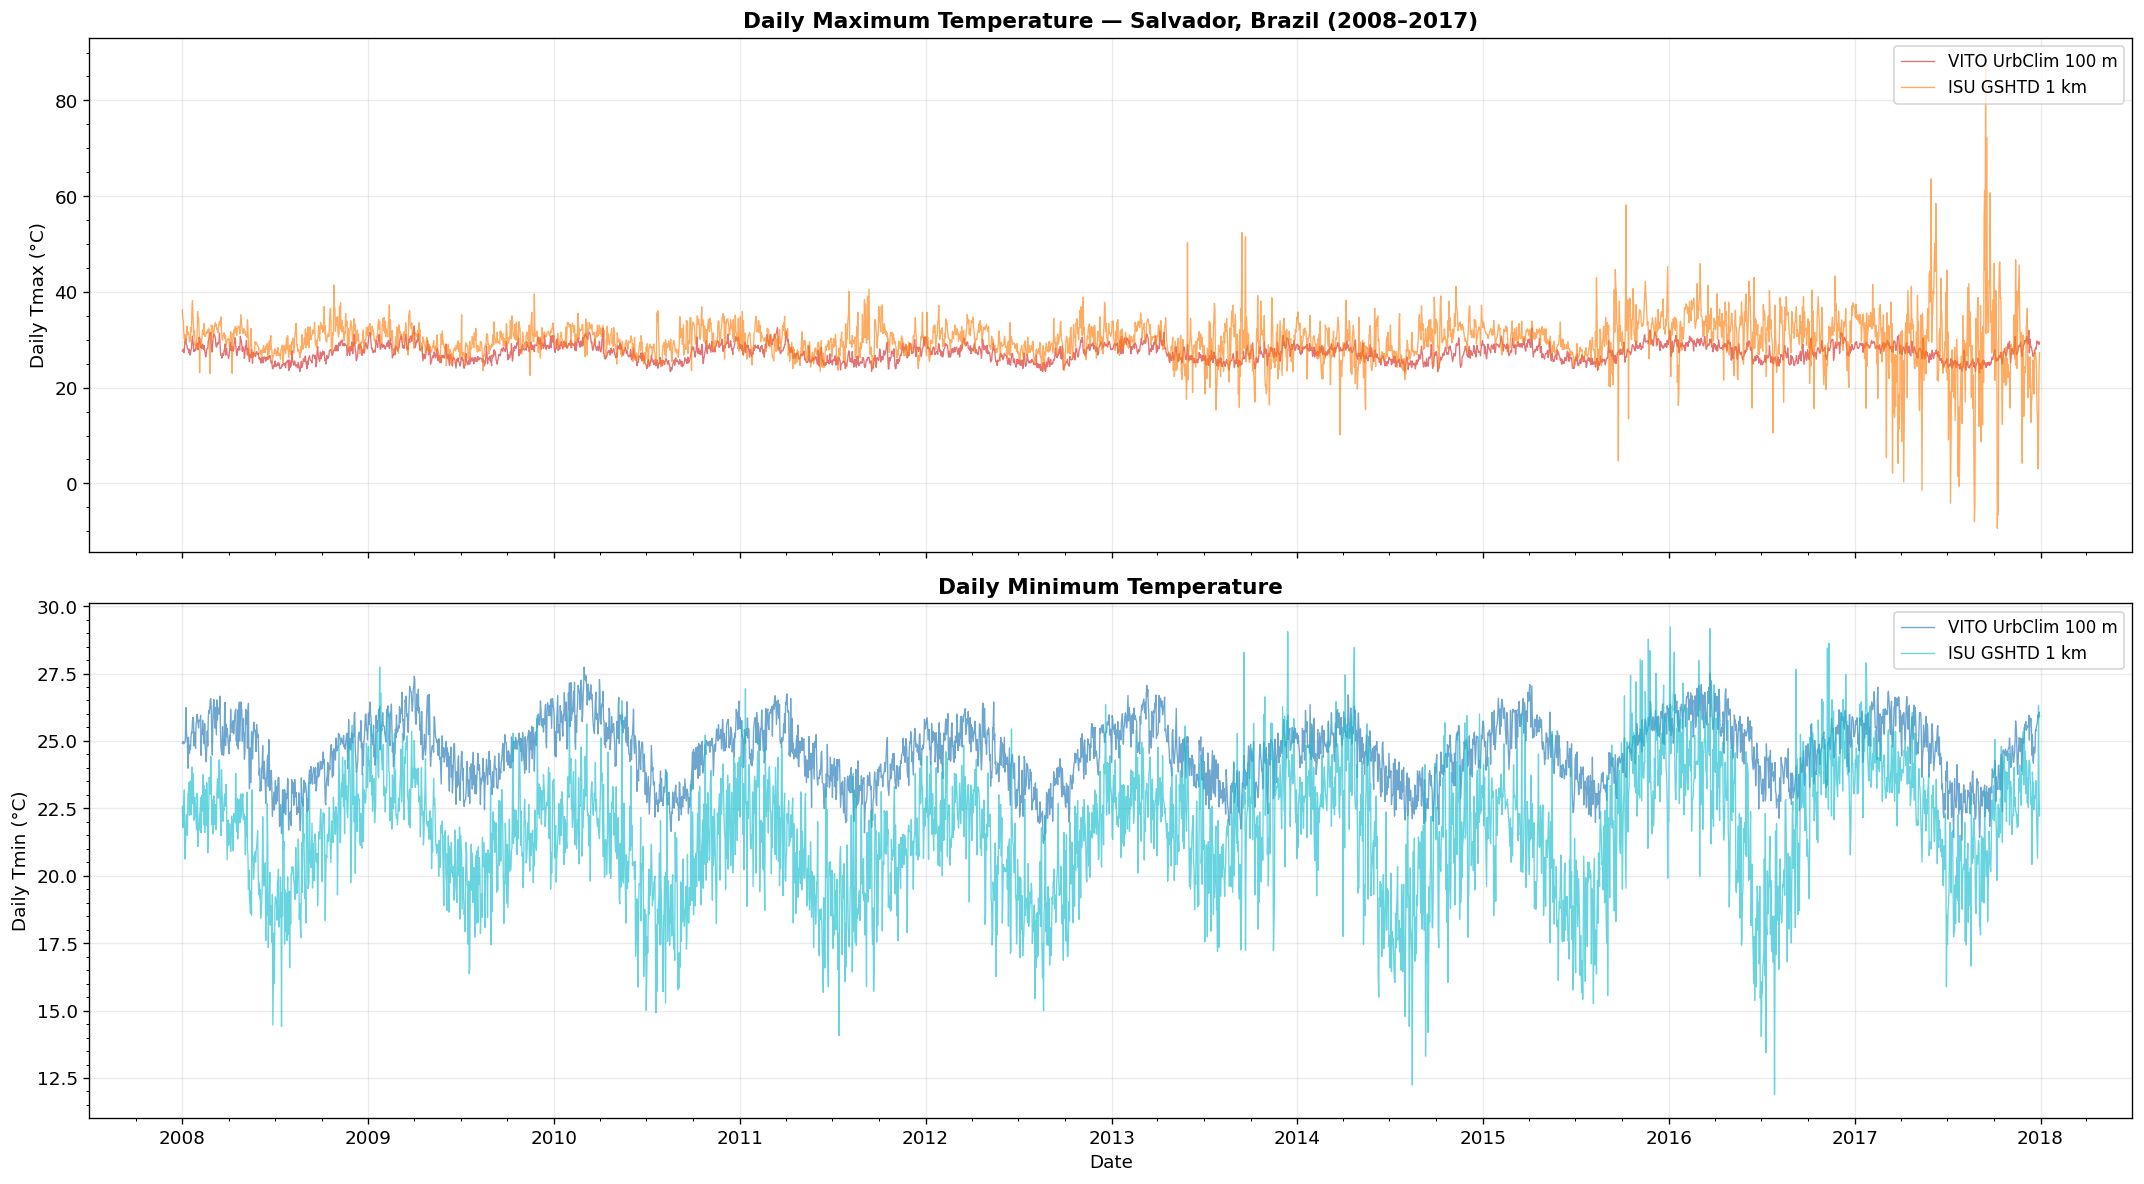

Saved: outputs/vito_vs_isu_daily_timeseries.png


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

ALPHA = 0.65
LW    = 0.8

# --- Tmax ---
ax = axes[0]
ax.plot(merged.date, merged.tmax_vito, color='#d62728', lw=LW, alpha=ALPHA, label='VITO UrbClim 100 m')
ax.plot(merged.date, merged.tmax_isu,  color='#ff7f0e', lw=LW, alpha=ALPHA, label='ISU GSHTD 1 km')
ax.set_ylabel('Daily Tmax (°C)', fontsize=11)
ax.set_title('Daily Maximum Temperature — Salvador, Brazil (2008–2017)', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.25)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())

# --- Tmin ---
ax = axes[1]
ax.plot(merged.date, merged.tmin_vito, color='#1f77b4', lw=LW, alpha=ALPHA, label='VITO UrbClim 100 m')
ax.plot(merged.date, merged.tmin_isu,  color='#17becf', lw=LW, alpha=ALPHA, label='ISU GSHTD 1 km')
ax.set_ylabel('Daily Tmin (°C)', fontsize=11)
ax.set_title('Daily Minimum Temperature', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.25)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())

# x-axis formatting
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=0, ha='center')
axes[1].set_xlabel('Date', fontsize=11)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'vito_vs_isu_daily_timeseries.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: outputs/vito_vs_isu_daily_timeseries.png')

## 6. Monthly percentile comparison — 90th, 95th, 99th

For each calendar month (pooling all years), compute the 90th, 95th, and 99th percentile of daily Tmax and Tmin separately for each dataset.

In [7]:
merged['month'] = merged.date.dt.month
PERCENTILES = [90, 95, 99]
MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

def monthly_percentiles(df, col):
    rows = []
    for m in range(1, 13):
        vals = df.loc[df['month'] == m, col]
        row = {'month': m}
        for p in PERCENTILES:
            row[f'p{p}'] = np.nanpercentile(vals, p)
        rows.append(row)
    return pd.DataFrame(rows)

pct_tmax_vito = monthly_percentiles(merged, 'tmax_vito')
pct_tmax_isu  = monthly_percentiles(merged, 'tmax_isu')
pct_tmin_vito = monthly_percentiles(merged, 'tmin_vito')
pct_tmin_isu  = monthly_percentiles(merged, 'tmin_isu')

print('Monthly percentiles computed')
print('\nTmax p95 sample:')
print(pd.DataFrame({'month': MONTH_LABELS,
                    'VITO p95': pct_tmax_vito.p95.round(2).values,
                    'ISU p95':  pct_tmax_isu.p95.round(2).values}).to_string(index=False))

Monthly percentiles computed

Tmax p95 sample:
month  VITO p95  ISU p95
  Jan     30.36    35.13
  Feb     30.24    36.71
  Mar     31.14    34.89
  Apr     30.31    34.61
  May     28.68    35.12
  Jun     27.96    37.11
  Jul     26.65    34.18
  Aug     26.95    35.79
  Sep     28.41    40.12
  Oct     29.20    38.24
  Nov     29.97    37.30
  Dec     30.69    36.28


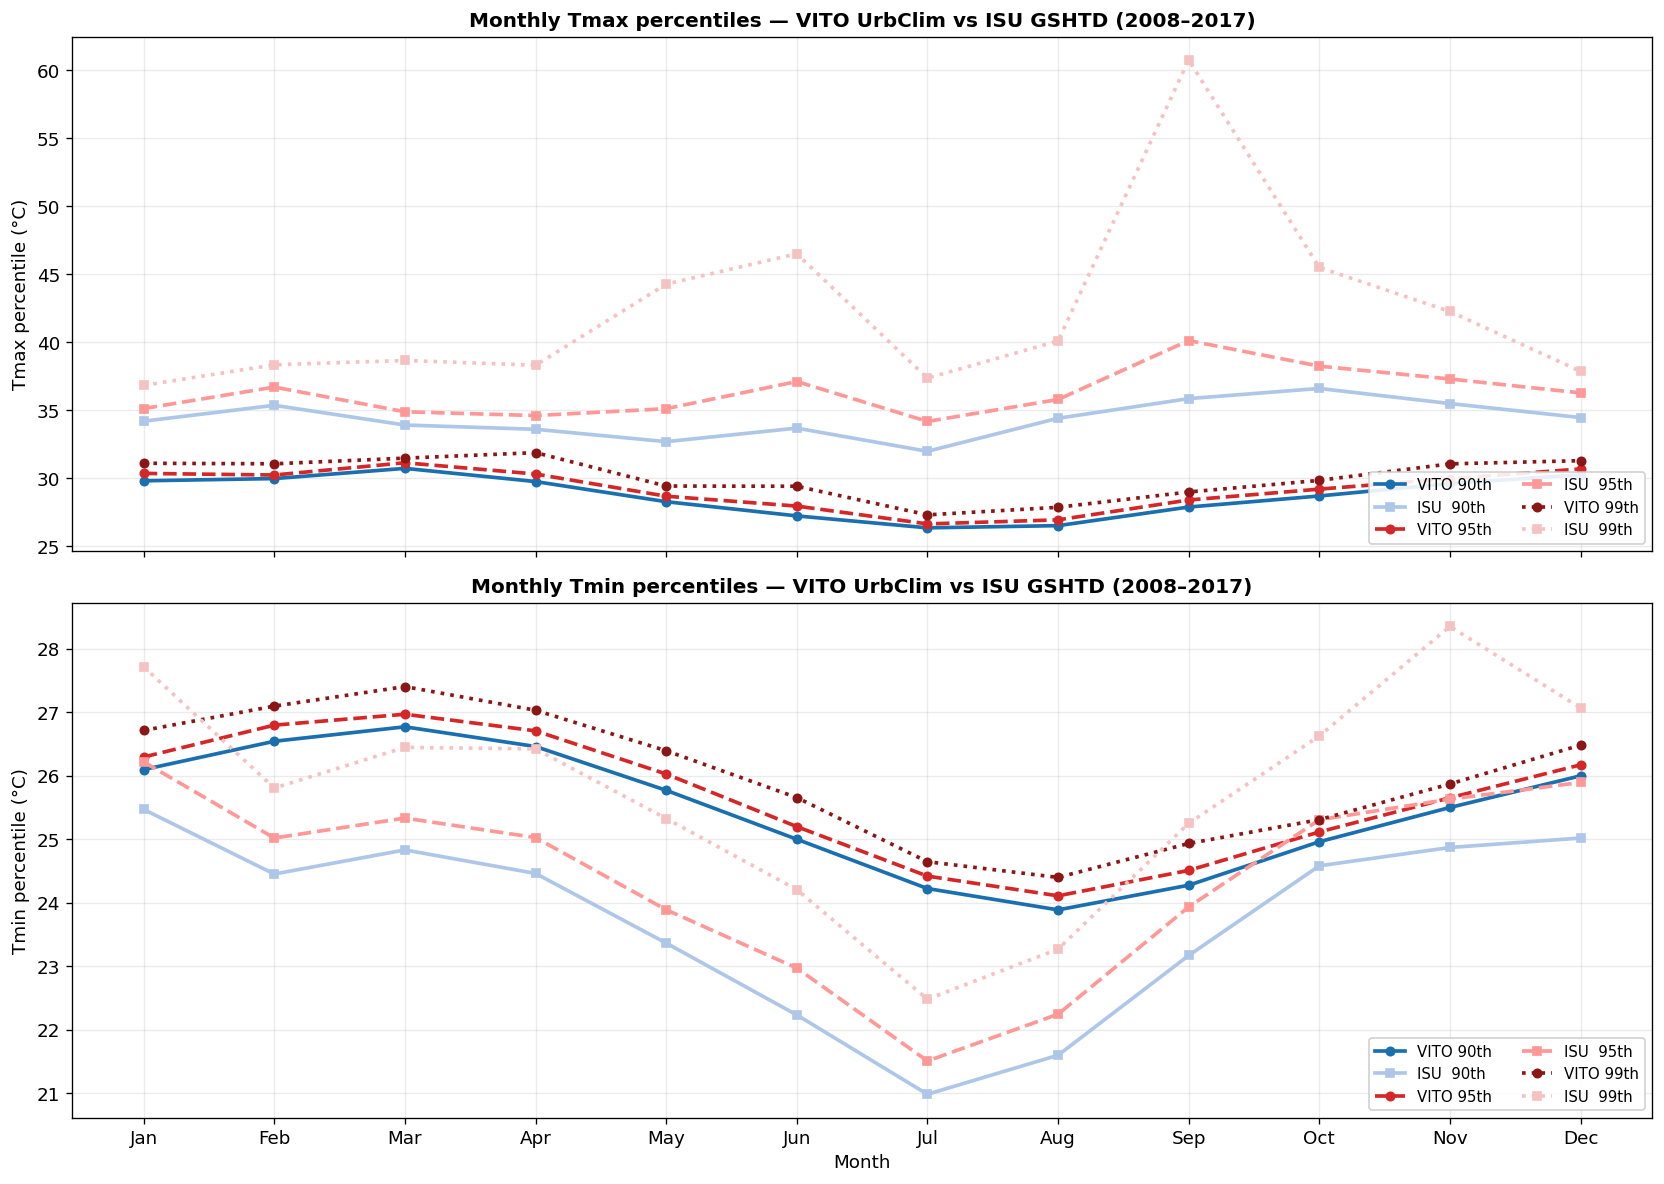

Saved: outputs/vito_vs_isu_monthly_percentiles.png


In [8]:
x = np.arange(1, 13)

COLORS_VITO = {'p90': '#1a6faf', 'p95': '#d62728', 'p99': '#8c1515'}   # blues/reds for VITO
COLORS_ISU  = {'p90': '#aec7e8', 'p95': '#ff9896', 'p99': '#f5c2c2'}   # lighter for ISU
STYLES = {'p90': '-', 'p95': '--', 'p99': ':'}

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for ax, pct_vito, pct_isu, var_label in [
    (axes[0], pct_tmax_vito, pct_tmax_isu, 'Tmax'),
    (axes[1], pct_tmin_vito, pct_tmin_isu, 'Tmin'),
]:
    for p in PERCENTILES:
        col = f'p{p}'
        ax.plot(x, pct_vito[col], color=COLORS_VITO[col], ls=STYLES[col], lw=2.2,
                marker='o', ms=5, label=f'VITO {p}th')
        ax.plot(x, pct_isu[col],  color=COLORS_ISU[col],  ls=STYLES[col], lw=2.2,
                marker='s', ms=5, label=f'ISU  {p}th')

    ax.set_ylabel(f'{var_label} percentile (°C)', fontsize=11)
    ax.set_title(f'Monthly {var_label} percentiles — VITO UrbClim vs ISU GSHTD (2008–2017)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.25)
    ax.legend(loc='lower right', ncol=2, fontsize=9, framealpha=0.9)

axes[1].set_xticks(x)
axes[1].set_xticklabels(MONTH_LABELS)
axes[1].set_xlabel('Month', fontsize=11)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'vito_vs_isu_monthly_percentiles.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: outputs/vito_vs_isu_monthly_percentiles.png')

## 7. Summary comparison table

In [9]:
from scipy import stats

def dataset_stats(col_vito, col_isu, label):
    v = merged[col_vito].dropna()
    i = merged[col_isu].dropna()
    common = merged[[col_vito, col_isu]].dropna()
    bias   = (common[col_isu] - common[col_vito]).mean()
    rmse   = np.sqrt(((common[col_isu] - common[col_vito]) ** 2).mean())
    r, _   = stats.pearsonr(common[col_vito], common[col_isu])

    rows = []
    for name, s in [('VITO UrbClim 100m', v), ('ISU GSHTD 1km', i)]:
        rows.append({
            'Variable': label,
            'Dataset':  name,
            'Mean (°C)': round(s.mean(), 2),
            'Std (°C)':  round(s.std(),  2),
            'Min (°C)':  round(s.min(),  2),
            'Max (°C)':  round(s.max(),  2),
            'p90 (°C)':  round(np.nanpercentile(s, 90), 2),
            'p95 (°C)':  round(np.nanpercentile(s, 95), 2),
            'p99 (°C)':  round(np.nanpercentile(s, 99), 2),
            'ISU–VITO bias (°C)': round(bias, 2) if name == 'ISU GSHTD 1km' else '',
            'RMSE (°C)':          round(rmse, 2) if name == 'ISU GSHTD 1km' else '',
            'Pearson r':          round(r, 3)    if name == 'ISU GSHTD 1km' else '',
        })
    return rows

summary_rows = (dataset_stats('tmax_vito', 'tmax_isu', 'Tmax') +
                dataset_stats('tmin_vito', 'tmin_isu', 'Tmin'))

summary = pd.DataFrame(summary_rows)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', '{:.2f}'.format)
print('=== Dataset Comparison Summary — Salvador 2008–2017 ===')
print(summary.to_string(index=False))

summary.to_csv(OUTPUT_DIR / 'vito_vs_isu_summary.csv', index=False)
print('\nSaved: outputs/vito_vs_isu_summary.csv')

=== Dataset Comparison Summary — Salvador 2008–2017 ===
Variable           Dataset  Mean (°C)  Std (°C)  Min (°C)  Max (°C)  p90 (°C)  p95 (°C)  p99 (°C) ISU–VITO bias (°C) RMSE (°C) Pearson r
    Tmax VITO UrbClim 100m      27.33      1.70     23.06     32.92     29.47     30.08     31.17                                       
    Tmax     ISU GSHTD 1km      29.96      4.98     -9.41     88.24     34.40     36.40     41.75               2.63      5.54      0.24
    Tmin VITO UrbClim 100m      24.59      1.16     21.20     27.74     26.07     26.37     26.88                                       
    Tmin     ISU GSHTD 1km      21.55      2.30     11.90     29.23     24.28     25.01     26.53              -3.04      3.56      0.60

Saved: outputs/vito_vs_isu_summary.csv


## 8. Bias scatter plots

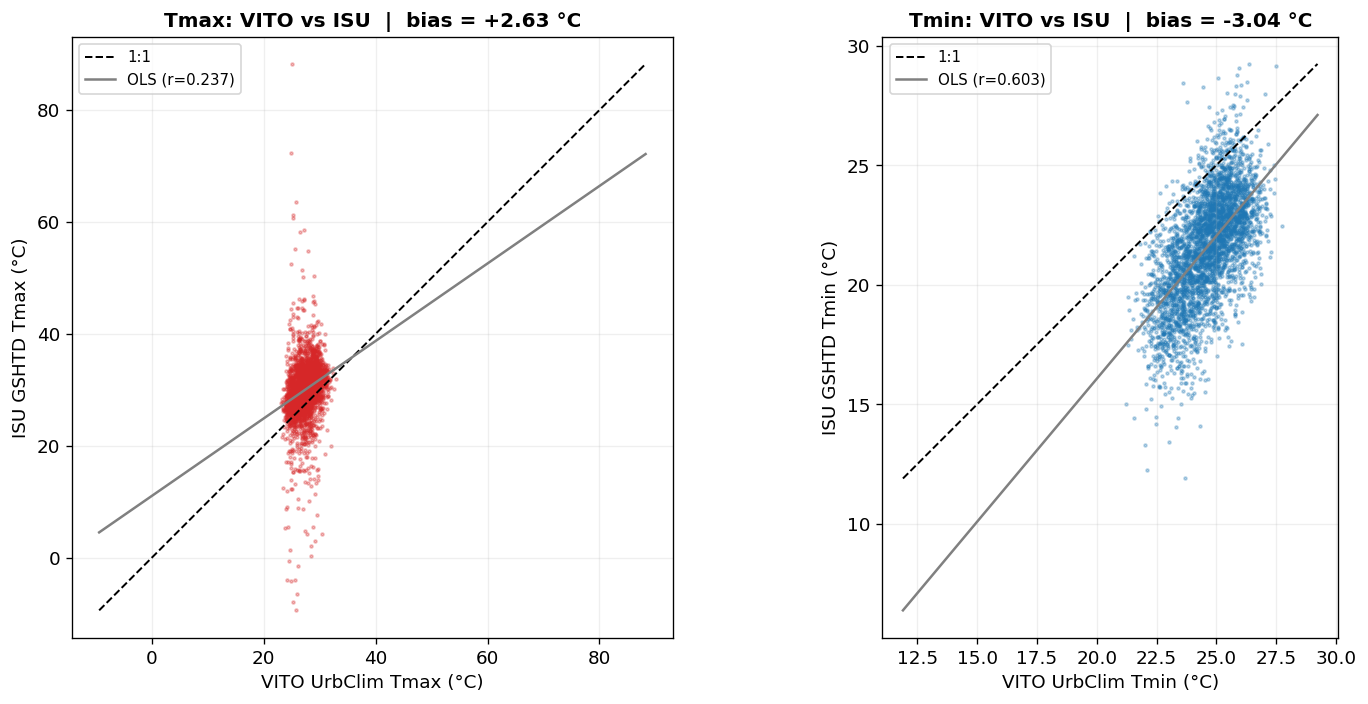

Saved: outputs/vito_vs_isu_scatter.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, vcol, icol, label, color in [
    (axes[0], 'tmax_vito', 'tmax_isu', 'Tmax', '#d62728'),
    (axes[1], 'tmin_vito', 'tmin_isu', 'Tmin', '#1f77b4'),
]:
    xy = merged[[vcol, icol]].dropna()
    ax.scatter(xy[vcol], xy[icol], s=3, alpha=0.3, color=color)

    # 1:1 line
    lim = [min(xy.min()), max(xy.max())]
    ax.plot(lim, lim, 'k--', lw=1.2, label='1:1')

    # Regression line
    m, b, r, *_ = stats.linregress(xy[vcol], xy[icol])
    xfit = np.array(lim)
    ax.plot(xfit, m * xfit + b, color='gray', lw=1.5, label=f'OLS (r={r:.3f})')

    bias = (xy[icol] - xy[vcol]).mean()
    ax.set_xlabel(f'VITO UrbClim {label} (°C)', fontsize=11)
    ax.set_ylabel(f'ISU GSHTD {label} (°C)', fontsize=11)
    ax.set_title(f'{label}: VITO vs ISU  |  bias = {bias:+.2f} °C', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)
    ax.set_aspect('equal', adjustable='box')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'vito_vs_isu_scatter.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: outputs/vito_vs_isu_scatter.png')

## 9. Monthly mean bias

How the ISU–VITO bias varies across the year.

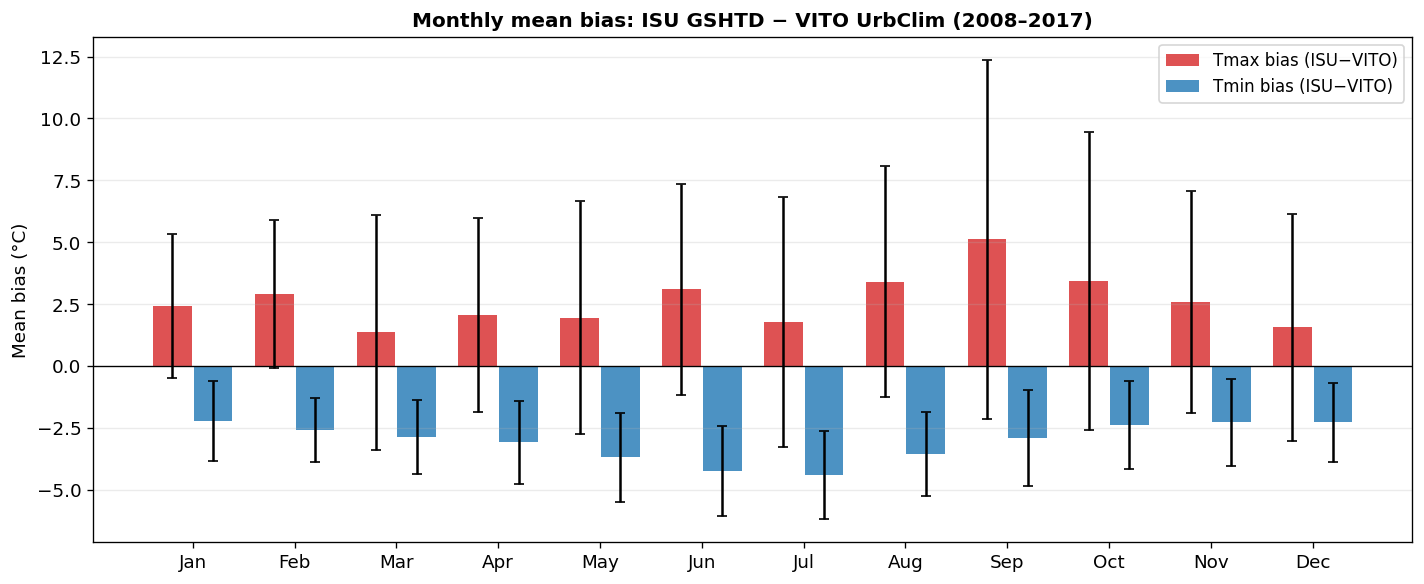

Saved: outputs/vito_vs_isu_monthly_bias.png


In [11]:
merged['bias_tmax'] = merged['tmax_isu'] - merged['tmax_vito']
merged['bias_tmin'] = merged['tmin_isu'] - merged['tmin_vito']

monthly_bias = merged.groupby('month')[['bias_tmax', 'bias_tmin']].mean()
monthly_bias_std = merged.groupby('month')[['bias_tmax', 'bias_tmin']].std()

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x - 0.2, monthly_bias['bias_tmax'], width=0.38, color='#d62728', alpha=0.8,
       yerr=monthly_bias_std['bias_tmax'], capsize=3, label='Tmax bias (ISU−VITO)')
ax.bar(x + 0.2, monthly_bias['bias_tmin'], width=0.38, color='#1f77b4', alpha=0.8,
       yerr=monthly_bias_std['bias_tmin'], capsize=3, label='Tmin bias (ISU−VITO)')

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(MONTH_LABELS)
ax.set_ylabel('Mean bias (°C)', fontsize=11)
ax.set_title('Monthly mean bias: ISU GSHTD − VITO UrbClim (2008–2017)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.25, axis='y')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'vito_vs_isu_monthly_bias.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: outputs/vito_vs_isu_monthly_bias.png')

## 10. Export merged daily data

In [12]:
export = merged[['date','tmax_vito','tmin_vito','tmax_isu','tmin_isu','bias_tmax','bias_tmin']].copy()
export['date'] = export['date'].dt.strftime('%Y-%m-%d')
export.to_csv(OUTPUT_DIR / 'vito_vs_isu_daily.csv', index=False)
print(f'Exported {len(export)} rows to outputs/vito_vs_isu_daily.csv')

Exported 3609 rows to outputs/vito_vs_isu_daily.csv
